# AstroWater AI - Treinamento de Machine Learning

Este notebook treina modelos supervisionados para prever potabilidade da agua usando o dataset publico `adityakadiwal/water-potability`, baixado com `kagglehub`.

No projeto AstroWater AI, este modulo complementa:

- o ESP32/Wokwi, que simula leituras de sensores;
- o motor de regras do backend;
- a visao computacional do Raspberry Pi;
- o dashboard e o relatorio com IA generativa.

Aviso: este modelo e uma POC educacional para triagem e nao substitui laudo laboratorial oficial.

In [62]:
!pip install joblib kagglehub matplotlib numpy pandas scikit-learn seaborn xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
from pathlib import Path
import json
import warnings

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'raw'
MODEL_DIR = BASE_DIR / 'models'
REPORT_DIR = BASE_DIR / 'reports'

for directory in [DATA_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

BASE_DIR

WindowsPath('c:/Users/felip/OneDrive/Documentos/FIAP 2 ano/gs1/machine-learning')

## 1. Download do dataset com KaggleHub

In [64]:
# Download latest version
path = kagglehub.dataset_download('adityakadiwal/water-potability')
print('Dataset baixado em:', path)

dataset_path = Path(path)
csv_files = list(dataset_path.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError('Nenhum CSV encontrado no dataset baixado.')

source_csv = csv_files[0]
local_csv = DATA_DIR / source_csv.name
df = pd.read_csv(source_csv)
df.to_csv(local_csv, index=False)

print('CSV usado:', source_csv.name)
print('Copia local:', local_csv)
df.head()

Dataset baixado em: C:\Users\felip\.cache\kagglehub\datasets\adityakadiwal\water-potability\versions\3
CSV usado: water_potability.csv
Copia local: c:\Users\felip\OneDrive\Documentos\FIAP 2 ano\gs1\machine-learning\data\raw\water_potability.csv


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Analise exploratoria rapida

Nesta etapa, a ideia e entender a qualidade do dataset antes de treinar. Isso ajuda a mostrar governanca de dados: volume, tipos, valores ausentes, distribuicoes, outliers, balanceamento da classe alvo e relacoes entre variaveis.


In [65]:
print("Linhas e colunas:", df.shape)
display(df.head())
display(df.info())

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})
display(profile.sort_values("missing_percent", ascending=False))

display(df.describe().T)


Linhas e colunas: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


None

,dtype,missing_values,missing_percent,unique_values
Sulfate,float64,781,23.84,2495
ph,float64,491,14.99,2785
Trihalomethanes,float64,162,4.95,3114
Hardness,float64,0,0.00,3276
Chloramines,float64,0,0.00,3276
Solids,float64,0,0.00,3276
Conductivity,float64,0,0.00,3276
Organic_carbon,float64,0,0.00,3276
Turbidity,float64,0,0.00,3276
Potability,int64,0,0.00,2


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


### Leitura dos valores ausentes

O dataset possui valores ausentes principalmente em variaveis quimicas. Em vez de apagar linhas, vamos comparar tecnicas de imputacao, pois remover dados pode reduzir a amostra e enviesar o treinamento.


,missing_values,missing_percent
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95
Hardness,0,0.00
Chloramines,0,0.00
Solids,0,0.00
Conductivity,0,0.00
Organic_carbon,0,0.00
Turbidity,0,0.00
Potability,0,0.00


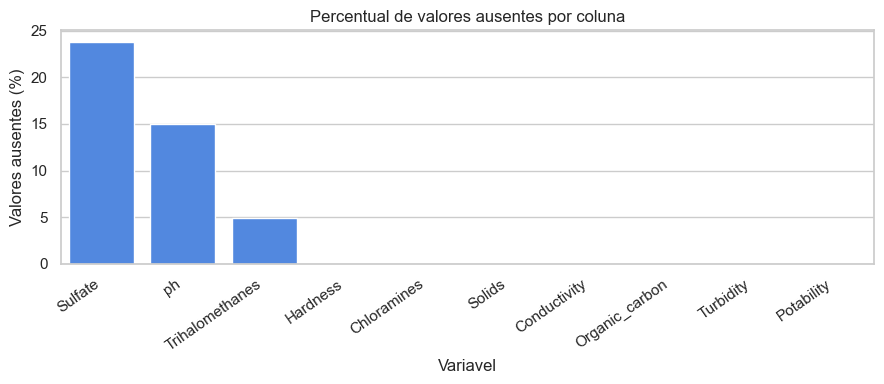

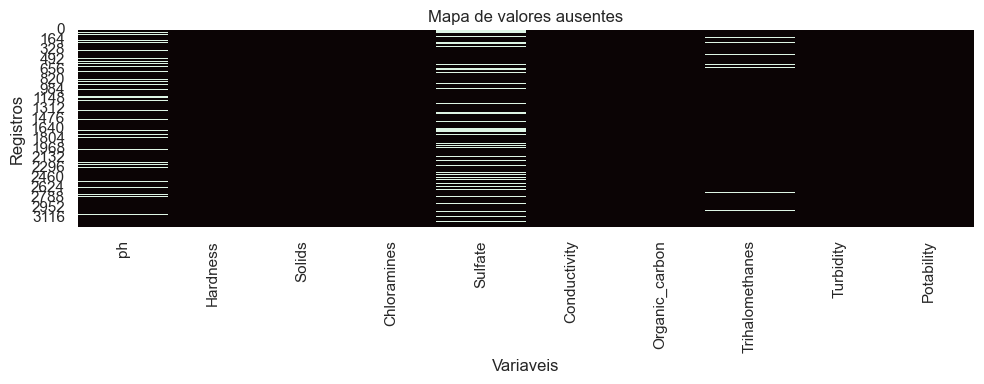

In [66]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_values")
    .assign(missing_percent=lambda data: (data["missing_values"] / len(df) * 100).round(2))
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

plt.figure(figsize=(9, 4))
sns.barplot(data=missing_summary.reset_index(), x="index", y="missing_percent", color="#3b82f6")
plt.title("Percentual de valores ausentes por coluna")
plt.xlabel("Variavel")
plt.ylabel("Valores ausentes (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "missing_values_percent.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap="mako")
plt.title("Mapa de valores ausentes")
plt.xlabel("Variaveis")
plt.ylabel("Registros")
plt.tight_layout()
plt.savefig(REPORT_DIR / "missing_values_heatmap.png", dpi=160)
plt.show()


### Balanceamento da classe alvo

A coluna `Potability` e o alvo: `0` representa agua nao potavel e `1` representa agua potavel. Se uma classe domina muito a outra, a acuracia pode enganar; por isso tambem acompanhamos F1, precision e recall.


,count,percent
Potability,,
0,1998,60.99
1,1278,39.01


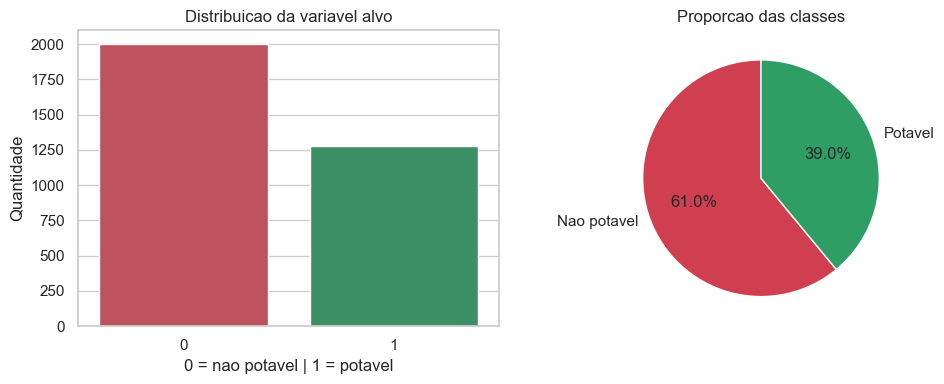

In [67]:
target_counts = df["Potability"].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)
target_table = pd.DataFrame({"count": target_counts, "percent": target_percent})
display(target_table)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x="Potability", palette=["#cf3f4f", "#2f9e65"], ax=axes[0])
axes[0].set_title("Distribuicao da variavel alvo")
axes[0].set_xlabel("0 = nao potavel | 1 = potavel")
axes[0].set_ylabel("Quantidade")

axes[1].pie(
    target_counts,
    labels=["Nao potavel", "Potavel"],
    autopct="%1.1f%%",
    colors=["#cf3f4f", "#2f9e65"],
    startangle=90,
)
axes[1].set_title("Proporcao das classes")
plt.tight_layout()
plt.savefig(REPORT_DIR / "target_distribution.png", dpi=160)
plt.show()


### Distribuicao e outliers

As distribuicoes ajudam a enxergar assimetria e possiveis outliers. Boxplots por classe mostram se alguma variavel separa bem agua potavel e nao potavel.


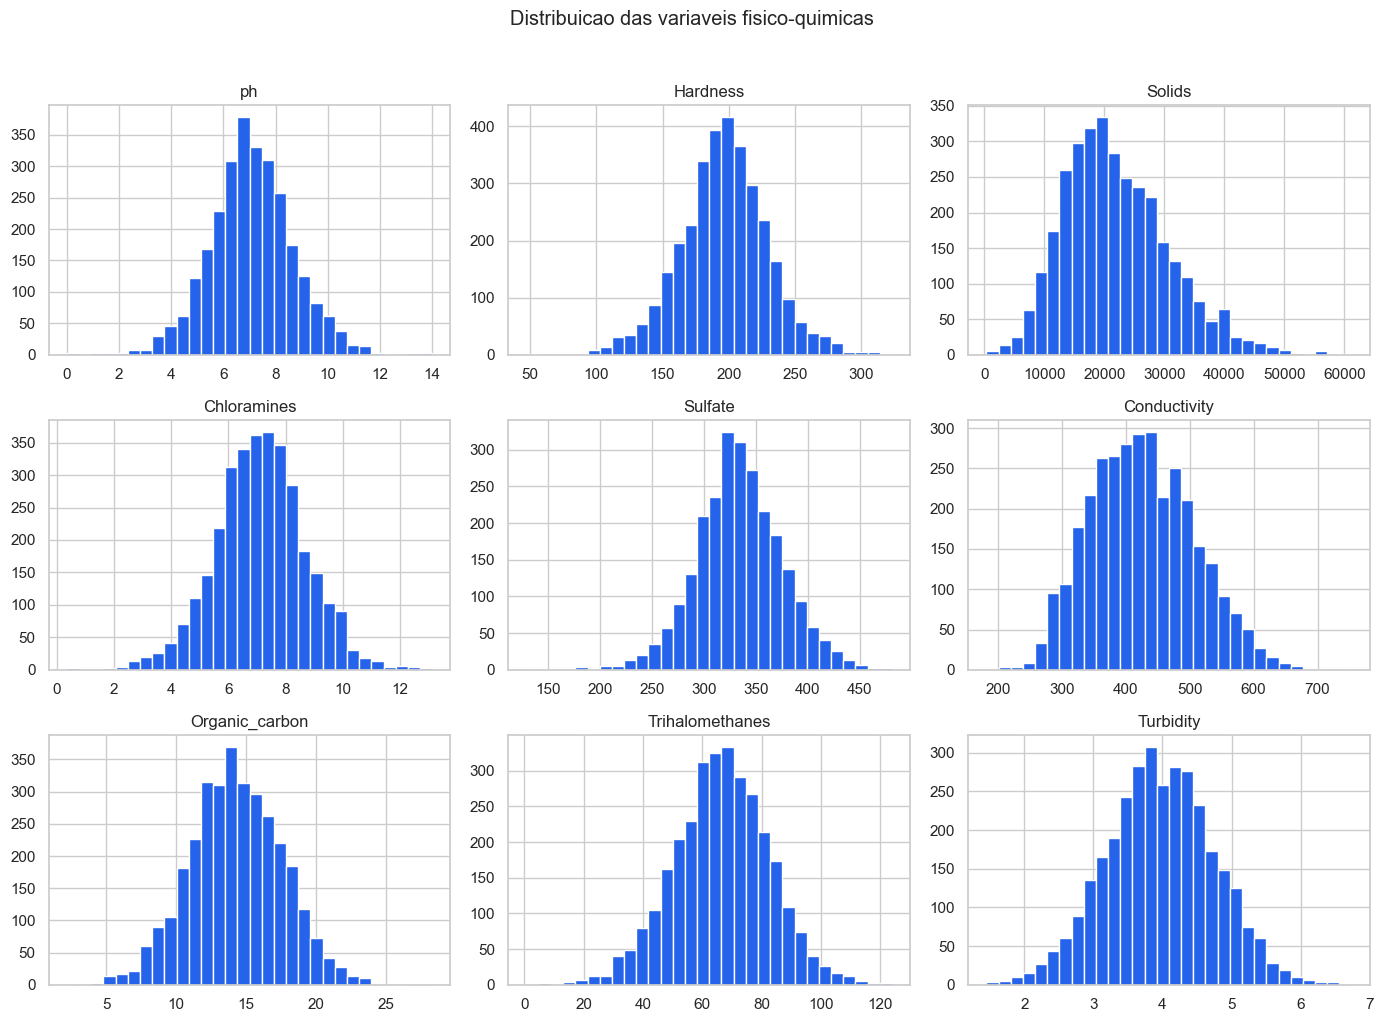

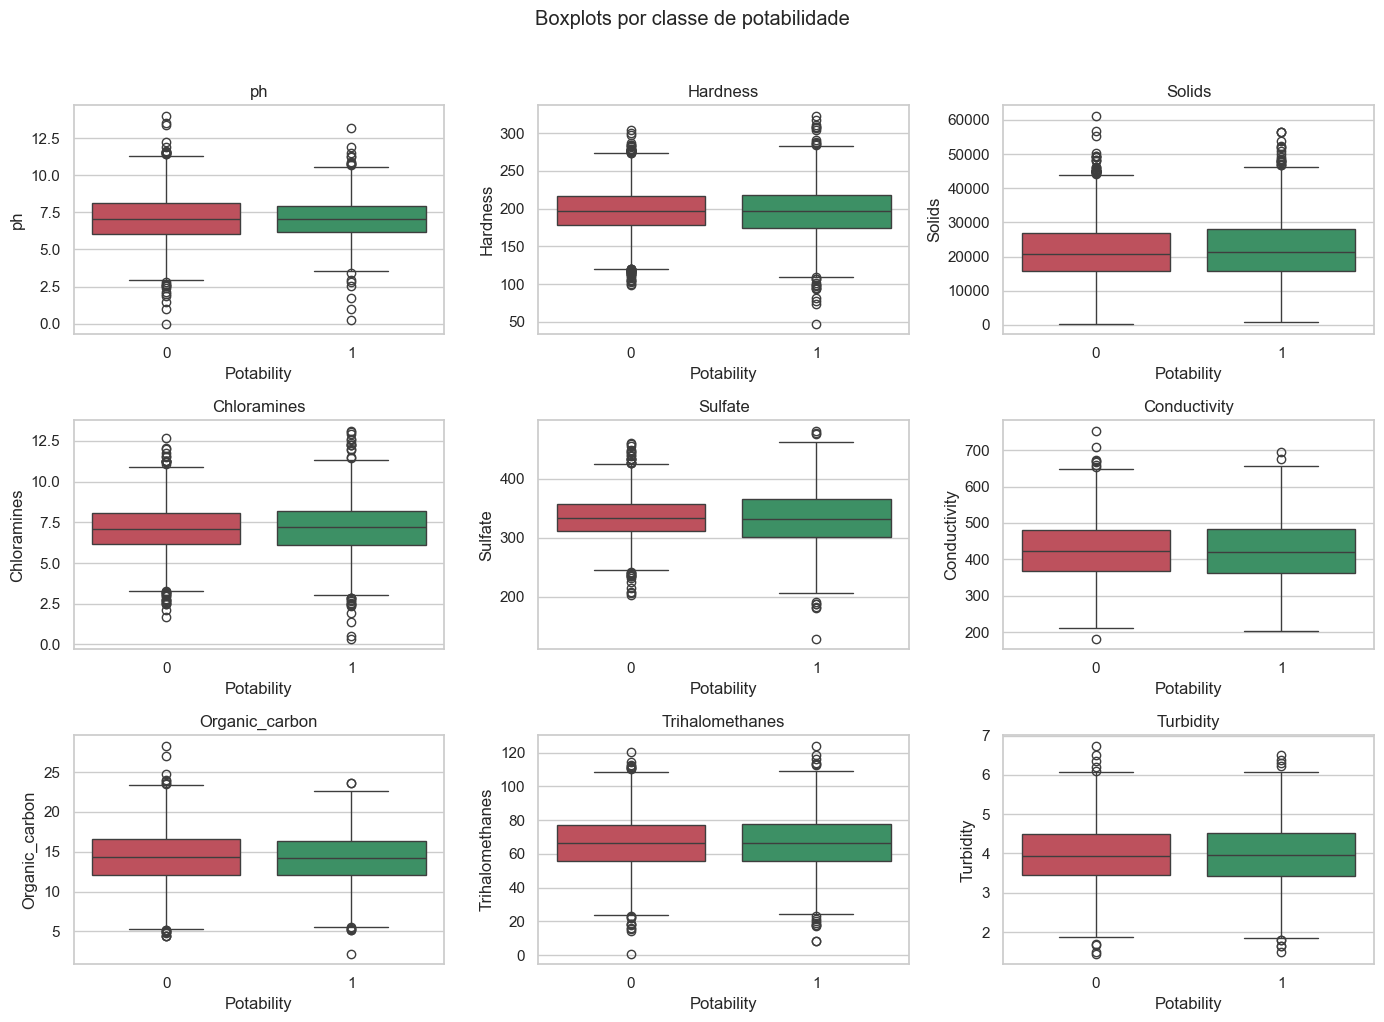

In [68]:
numeric_columns = [column for column in df.columns if column != "Potability"]

df[numeric_columns].hist(figsize=(14, 10), bins=30, color="#2563eb", edgecolor="white")
plt.suptitle("Distribuicao das variaveis fisico-quimicas", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "feature_distributions.png", dpi=160)
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for axis, column in zip(axes.ravel(), numeric_columns):
    sns.boxplot(data=df, x="Potability", y=column, ax=axis, palette=["#cf3f4f", "#2f9e65"])
    axis.set_title(column)
    axis.set_xlabel("Potability")
plt.suptitle("Boxplots por classe de potabilidade", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "boxplots_by_potability.png", dpi=160)
plt.show()


### Correlacoes e relacoes entre variaveis

A matriz de correlacao ajuda a identificar redundancia ou relacoes lineares. No dataset de potabilidade, a separacao costuma ser sutil, entao e normal nao aparecer uma variavel isolada resolvendo o problema.


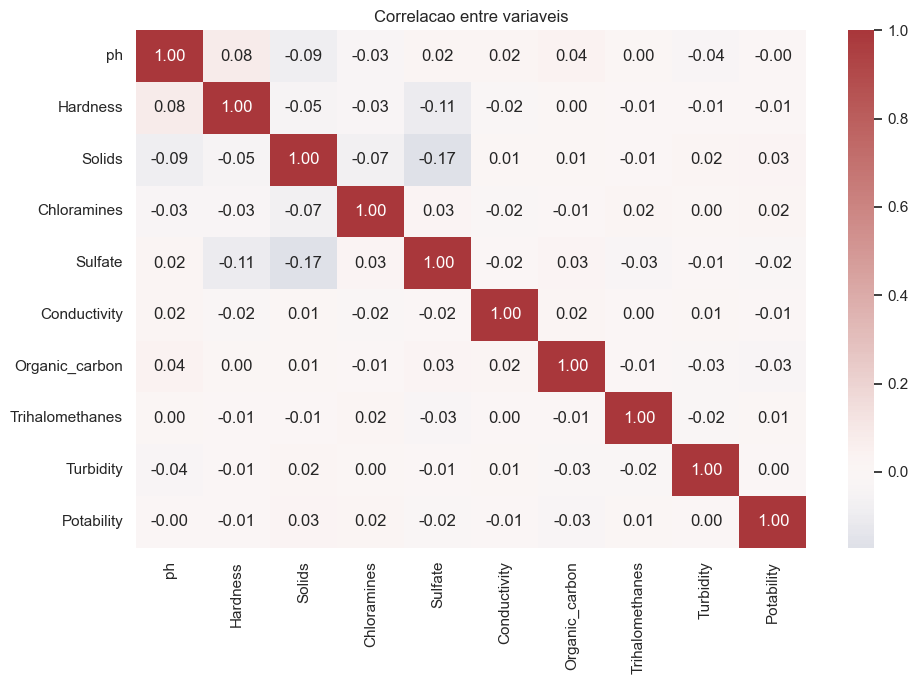

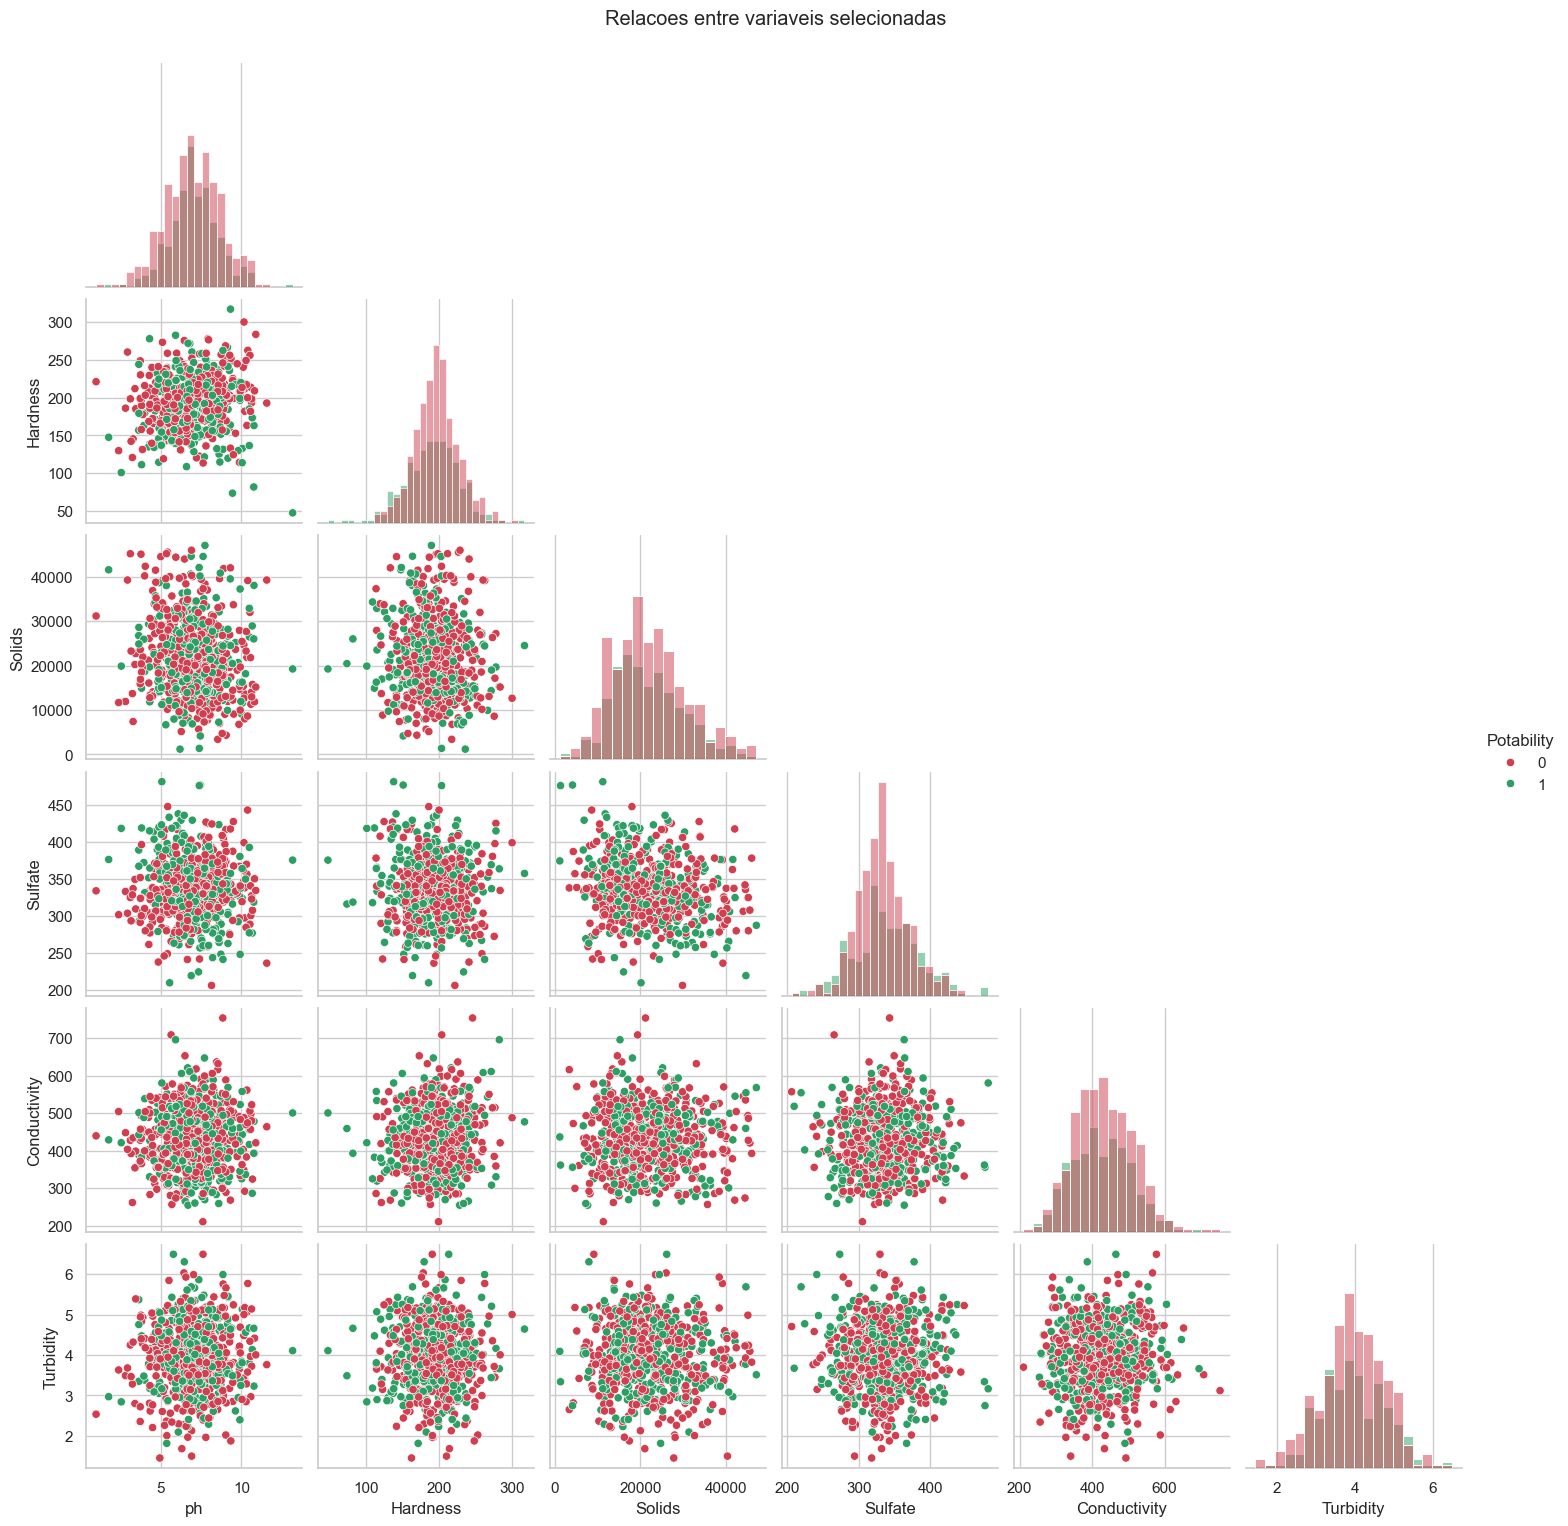

In [69]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlacao entre variaveis")
plt.tight_layout()
plt.savefig(REPORT_DIR / "correlation_heatmap.png", dpi=160)
plt.show()

selected_pairplot_columns = ["ph", "Hardness", "Solids", "Sulfate", "Conductivity", "Turbidity", "Potability"]
pairplot_df = df[selected_pairplot_columns].dropna().sample(
    n=min(700, len(df[selected_pairplot_columns].dropna())),
    random_state=RANDOM_STATE,
)
pair_grid = sns.pairplot(
    pairplot_df,
    hue="Potability",
    diag_kind="hist",
    palette={0: "#cf3f4f", 1: "#2f9e65"},
    corner=True,
)
pair_grid.fig.suptitle("Relacoes entre variaveis selecionadas", y=1.02)
pair_grid.savefig(REPORT_DIR / "pairplot_selected_features.png", dpi=160)
plt.show()


## 3. Preparacao e tratamento dos dados

O dataset possui valores ausentes em algumas colunas. Em vez de usar uma unica estrategia fixa, vamos comparar diferentes imputadores e selecionar o melhor para o pipeline principal.


In [70]:
target = "Potability"
features = [column for column in df.columns if column != target]

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Features:", features)


Treino: (2620, 9)
Teste: (656, 9)
Features: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


### Comparacao de estrategias de imputacao

Vamos comparar quatro formas de preencher valores vazios:

- **Media**: simples, mas sensivel a outliers.
- **Mediana**: robusta para distribuicoes assimetricas.
- **KNNImputer**: usa vizinhos parecidos para estimar valores ausentes.
- **Regressao linear iterativa**: estima cada coluna ausente a partir das demais variaveis, repetindo o processo ate estabilizar.

A comparacao abaixo usa validacao cruzada no conjunto de treino e seleciona a estrategia com melhor F1 medio.


In [71]:
imputer_candidates = {
    "Media": SimpleImputer(strategy="mean"),
    "Mediana": SimpleImputer(strategy="median"),
    "knn": KNNImputer(n_neighbors=5, weights="distance"),
    "regressao_linear_iterativa": IterativeImputer(
        estimator=LinearRegression(),
        max_iter=20,
        initial_strategy="median",
        random_state=RANDOM_STATE,
        skip_complete=True,
    ),
}

imputation_rows = []
imputation_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for imputer_name, imputer in imputer_candidates.items():
    candidate_preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(steps=[
                ("imputer", imputer),
                ("scaler", StandardScaler()),
            ]), features)
        ],
        remainder="drop",
    )
    candidate_pipeline = Pipeline(steps=[
        ("preprocessor", candidate_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])
    scores = cross_validate(
        candidate_pipeline,
        X_train,
        y_train,
        cv=imputation_cv,
        scoring={"accuracy": "accuracy", "f1": "f1", "recall": "recall", "roc_auc": "roc_auc"},
        n_jobs=1,
    )
    imputation_rows.append({
        "imputer": imputer_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
    })

imputation_results = pd.DataFrame(imputation_rows).sort_values("f1_mean", ascending=False)
imputation_results.to_csv(REPORT_DIR / "imputation_comparison.csv", index=False)
display(imputation_results)

selected_imputer_name = imputation_results.iloc[0]["imputer"]
selected_imputer = imputer_candidates[selected_imputer_name]
print("Imputador selecionado:", selected_imputer_name)


,imputer,accuracy_mean,f1_mean,recall_mean,roc_auc_mean
0,Media,0.675954,0.467899,0.366906,0.693682
3,regressao_linear_iterativa,0.673282,0.461223,0.360033,0.687523
1,Mediana,0.670611,0.457905,0.358106,0.693222
2,knn,0.667557,0.455888,0.359053,0.690382


Imputador selecionado: Media


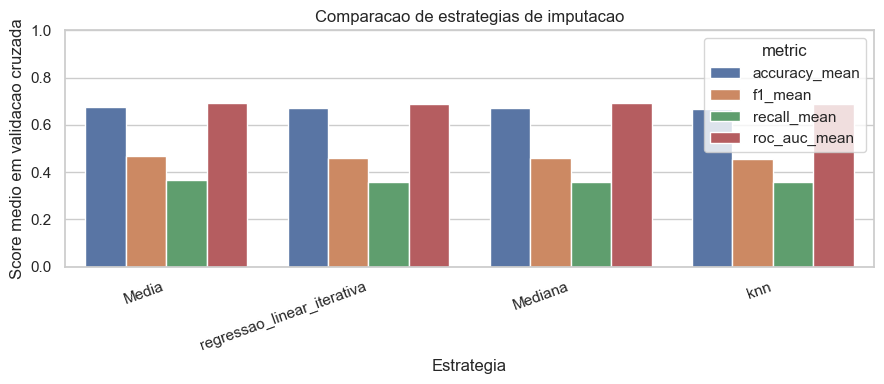

In [72]:
plt.figure(figsize=(9, 4))
plot_imputation = imputation_results.melt(
    id_vars="imputer",
    value_vars=["accuracy_mean", "f1_mean", "recall_mean", "roc_auc_mean"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_imputation, x="imputer", y="score", hue="metric")
plt.title("Comparacao de estrategias de imputacao")
plt.xlabel("Estrategia")
plt.ylabel("Score medio em validacao cruzada")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "imputation_comparison.png", dpi=160)
plt.show()


### Pipeline final de preprocessing

A partir da comparacao, o pipeline principal passa a usar o imputador selecionado. Isso deixa a decisao documentada e reproduzivel.


In [73]:
numeric_preprocessor = Pipeline(steps=[
    ("imputer", selected_imputer),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[("numeric", numeric_preprocessor, features)],
    remainder="drop",
)

preprocessor


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['ph', 'Hardness', 'Solids', 'Chloramines',
                                  'Sulfate', 'Conductivity', 'Organic_carbon',
                                  'Trihalomethanes', 'Turbidity'])])

## 4. Treinamento de varios modelos

In [74]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=350,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM RBF': SVC(kernel='rbf', C=2.0, probability=True, class_weight='balanced', random_state=RANDOM_STATE),
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score='raise',
    )
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values('f1_mean', ascending=False)
cv_results.to_csv(REPORT_DIR / 'cross_validation_results.csv', index=False)
display(cv_results)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
6,SVM RBF,0.666794,0.006677,0.570411,0.005092,0.589981,0.048508,0.579120,0.023843,0.705115,0.019029
5,Hist Gradient Boosting,0.653817,0.008327,0.580605,0.021028,0.411918,0.036485,0.480556,0.022199,0.668579,0.009689
3,Random Forest,0.670992,0.006891,0.642208,0.017027,0.355151,0.034253,0.456202,0.027154,0.694475,0.013383
2,Decision Tree,0.616794,0.020497,0.527268,0.041922,0.387724,0.120015,0.430679,0.064929,0.609036,0.018964
0,Logistic Regression,0.496183,0.016328,0.380081,0.019281,0.464840,0.044984,0.417831,0.028141,0.476709,0.017935
1,KNN,0.641603,0.011912,0.584591,0.026098,0.276872,0.038854,0.374770,0.038577,0.653870,0.014566
4,Gradient Boosting,0.641603,0.011851,0.597780,0.041550,0.250488,0.028113,0.352192,0.030320,0.630123,0.025710


## 5. Avaliacao no conjunto de teste

Para a POC, o melhor modelo sera escolhido por `F1-score`, pois queremos equilibrar precisao e recall. Em um projeto real de saude/saneamento, tambem faria sentido priorizar recall para reduzir falso negativo de agua impropria.

In [75]:
test_rows = []

for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline.named_steps['model'], 'predict_proba'):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    test_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_score),
    })

test_results = pd.DataFrame(test_rows).sort_values('f1', ascending=False)
test_results.to_csv(REPORT_DIR / 'test_results.csv', index=False)
display(test_results)

best_model_name = test_results.iloc[0]['model']
best_pipeline = trained_pipelines[best_model_name]
print('Melhor modelo:', best_model_name)

,model,accuracy,precision,recall,f1,roc_auc
6,SVM RBF,0.615854,0.507937,0.500000,0.503937,0.645342
5,Hist Gradient Boosting,0.670732,0.628205,0.382812,0.475728,0.643369
0,Logistic Regression,0.527439,0.418182,0.539062,0.470990,0.548008
3,Random Forest,0.657012,0.613139,0.328125,0.427481,0.654912
2,Decision Tree,0.647866,0.606838,0.277344,0.380697,0.610220
4,Gradient Boosting,0.657012,0.656566,0.253906,0.366197,0.659053
1,KNN,0.620427,0.529915,0.242188,0.332440,0.614121


Melhor modelo: SVM RBF


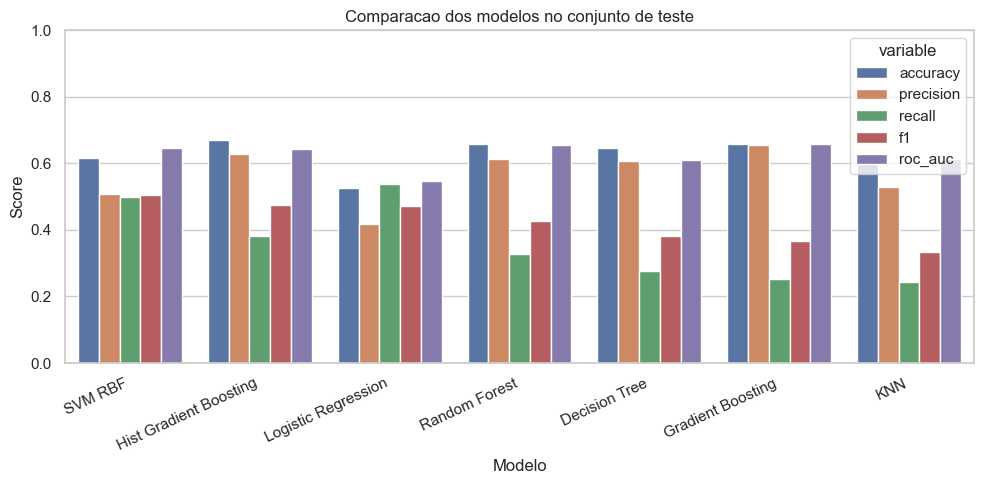

In [76]:
plt.figure(figsize=(10, 5))
plot_df = test_results.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
sns.barplot(data=plot_df, x='model', y='value', hue='variable')
plt.title('Comparacao dos modelos no conjunto de teste')
plt.ylabel('Score')
plt.xlabel('Modelo')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'model_comparison.png', dpi=160)
plt.show()

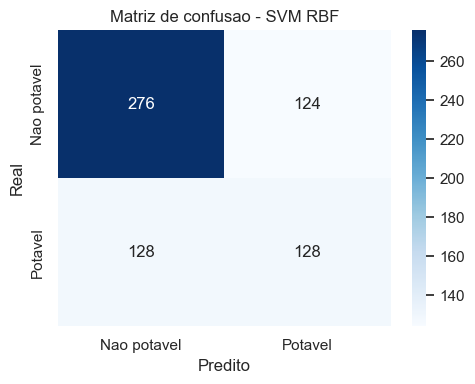

              precision    recall  f1-score   support

 nao potavel       0.68      0.69      0.69       400
     potavel       0.51      0.50      0.50       256

    accuracy                           0.62       656
   macro avg       0.60      0.59      0.60       656
weighted avg       0.61      0.62      0.62       656



In [77]:
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nao potavel', 'Potavel'], yticklabels=['Nao potavel', 'Potavel'])
plt.title(f'Matriz de confusao - {best_model_name}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'best_model_confusion_matrix.png', dpi=160)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['nao potavel', 'potavel']))

## 6. Treinamento iterativo ate 2000 epocas

Alguns modelos classicos, como Random Forest, KNN e arvore de decisao, nao treinam por epocas. Para acompanhar evolucao do aprendizado, esta secao usa modelos iterativos:

- `MLPClassifier`: rede neural simples para dados tabulares.
- `SGDClassifier`: classificador linear treinado incrementalmente.
- `GradientBoostingClassifier`: acompanhamento por estagios usando `staged_predict`.

A ideia e comparar acuracia e F1 ao longo de ate 2000 epocas/estagios. O F1 e importante porque o dataset e desbalanceado e acuracia sozinha pode enganar.


In [78]:
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=ConvergenceWarning)

EPOCHS = 2000

# Separacao treino/validacao para acompanhar evolucao sem tocar no teste final.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

preprocessor_epoch = clone(preprocessor)
X_fit_prepared = preprocessor_epoch.fit_transform(X_fit)
X_val_prepared = preprocessor_epoch.transform(X_val)
X_test_prepared = preprocessor_epoch.transform(X_test)

sample_weight = compute_sample_weight(class_weight="balanced", y=y_fit)
classes = np.array([0, 1])

epoch_rows = []

def add_epoch_metrics(model_name, epoch, model, loss=None):
    train_pred = model.predict(X_fit_prepared)
    val_pred = model.predict(X_val_prepared)
    epoch_rows.append({
        "model": model_name,
        "epoch": epoch,
        "train_accuracy": accuracy_score(y_fit, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "train_f1": f1_score(y_fit, train_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "loss": loss,
    })

mlp_epoch_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE,
)

sgd_epoch_model = SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha=0.0005,
    l1_ratio=0.15,
    learning_rate="optimal",
    random_state=RANDOM_STATE,
)

for epoch in range(1, EPOCHS + 1):
    mlp_epoch_model.fit(X_fit_prepared, y_fit)
    add_epoch_metrics("MLP Neural Network", epoch, mlp_epoch_model, getattr(mlp_epoch_model, "loss_", None))

    sgd_epoch_model.partial_fit(
        X_fit_prepared,
        y_fit,
        classes=classes,
        sample_weight=sample_weight,
    )
    add_epoch_metrics("SGD Logistic", epoch, sgd_epoch_model)

epoch_results = pd.DataFrame(epoch_rows)
epoch_results.to_csv(REPORT_DIR / "epoch_training_curves.csv", index=False)

display(
    epoch_results
    .sort_values("val_f1", ascending=False)
    .groupby("model")
    .head(5)
    .sort_values(["model", "val_f1"], ascending=[True, False])
)


,model,epoch,train_accuracy,val_accuracy,train_f1,val_f1,loss
3542,MLP Neural Network,1772,0.971374,0.656489,0.963459,0.585253,0.123472
3578,MLP Neural Network,1790,0.970897,0.656489,0.963008,0.585253,0.121043
3636,MLP Neural Network,1819,0.973282,0.660305,0.965937,0.584112,0.116893
3498,MLP Neural Network,1750,0.971374,0.662214,0.963235,0.583529,0.125563
3102,MLP Neural Network,1552,0.969466,0.662214,0.961306,0.583529,0.135649
49,SGD Logistic,25,0.457061,0.456107,0.477022,0.486486,NaN
47,SGD Logistic,24,0.457538,0.454198,0.476760,0.485612,NaN
53,SGD Logistic,27,0.455153,0.458015,0.473733,0.485507,NaN
45,SGD Logistic,23,0.459924,0.458015,0.479301,0.485507,NaN
51,SGD Logistic,26,0.456107,0.452290,0.475621,0.482883,NaN


In [79]:
gradient_stage_model = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", GradientBoostingClassifier(
        n_estimators=EPOCHS,
        learning_rate=0.03,
        max_depth=3,
        random_state=RANDOM_STATE,
    )),
])

gradient_stage_model.fit(X_fit, y_fit)
gb_model = gradient_stage_model.named_steps["model"]
gb_preprocessor = gradient_stage_model.named_steps["preprocessor"]
X_fit_gb = gb_preprocessor.transform(X_fit)
X_val_gb = gb_preprocessor.transform(X_val)

gb_rows = []
for stage, (train_pred, val_pred) in enumerate(
    zip(gb_model.staged_predict(X_fit_gb), gb_model.staged_predict(X_val_gb)),
    start=1,
):
    gb_rows.append({
        "model": "Gradient Boosting Staged",
        "epoch": stage,
        "train_accuracy": accuracy_score(y_fit, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "train_f1": f1_score(y_fit, train_pred, zero_division=0),
        "val_f1": f1_score(y_val, val_pred, zero_division=0),
        "loss": None,
    })

gb_epoch_results = pd.DataFrame(gb_rows)
epoch_results = pd.concat([epoch_results, gb_epoch_results], ignore_index=True)
epoch_results.to_csv(REPORT_DIR / "epoch_training_curves.csv", index=False)

best_epochs = (
    epoch_results
    .sort_values("val_f1", ascending=False)
    .groupby("model")
    .head(1)
    .sort_values("val_f1", ascending=False)
)
display(best_epochs)


,model,epoch,train_accuracy,val_accuracy,train_f1,val_f1,loss
3578,MLP Neural Network,1790,0.970897,0.656489,0.963008,0.585253,0.121043
49,SGD Logistic,25,0.457061,0.456107,0.477022,0.486486,NaN
5922,Gradient Boosting Staged,1923,0.964218,0.658397,0.952138,0.484150,NaN


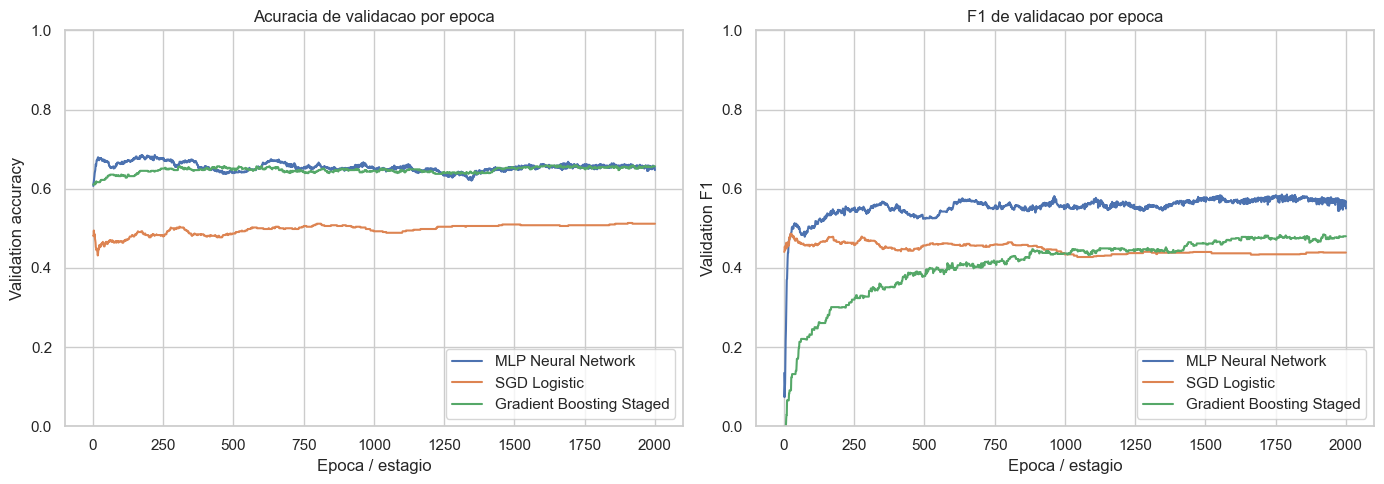

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.lineplot(data=epoch_results, x="epoch", y="val_accuracy", hue="model", ax=axes[0])
axes[0].set_title("Acuracia de validacao por epoca")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Validation accuracy")

sns.lineplot(data=epoch_results, x="epoch", y="val_f1", hue="model", ax=axes[1])
axes[1].set_title("F1 de validacao por epoca")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Validation F1")

for axis in axes:
    axis.set_xlabel("Epoca / estagio")
    axis.legend(loc="lower right")

plt.tight_layout()
plt.savefig(REPORT_DIR / "epoch_training_curves.png", dpi=160)
plt.show()


In [81]:
best_epoch_row = best_epochs.iloc[0]
best_epoch_model_name = best_epoch_row["model"]
best_epoch_number = int(best_epoch_row["epoch"])

print(f"Melhor modelo iterativo: {best_epoch_model_name} na epoca/estagio {best_epoch_number}")
print(f"Val accuracy: {best_epoch_row['val_accuracy']:.4f}")
print(f"Val F1: {best_epoch_row['val_f1']:.4f}")

if best_epoch_model_name == "MLP Neural Network":
    final_epoch_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.001,
            learning_rate_init=0.001,
            max_iter=best_epoch_number,
            random_state=RANDOM_STATE,
        )),
    ])
elif best_epoch_model_name == "SGD Logistic":
    final_epoch_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=0.0005,
            l1_ratio=0.15,
            max_iter=best_epoch_number,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ])
else:
    final_epoch_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", GradientBoostingClassifier(
            n_estimators=best_epoch_number,
            learning_rate=0.03,
            max_depth=3,
            random_state=RANDOM_STATE,
        )),
    ])

final_epoch_pipeline.fit(X_train, y_train)
epoch_test_pred = final_epoch_pipeline.predict(X_test)

epoch_test_summary = {
    "model": best_epoch_model_name,
    "epochs": best_epoch_number,
    "accuracy": accuracy_score(y_test, epoch_test_pred),
    "precision": precision_score(y_test, epoch_test_pred, zero_division=0),
    "recall": recall_score(y_test, epoch_test_pred, zero_division=0),
    "f1": f1_score(y_test, epoch_test_pred, zero_division=0),
}

display(pd.DataFrame([epoch_test_summary]))
joblib.dump(final_epoch_pipeline, MODEL_DIR / "astrowater_best_epoch_model.joblib")


Melhor modelo iterativo: MLP Neural Network na epoca/estagio 1790
Val accuracy: 0.6565
Val F1: 0.5853


,model,epochs,accuracy,precision,recall,f1
0,MLP Neural Network,1790,0.565549,0.438819,0.40625,0.421907


['c:\\Users\\felip\\OneDrive\\Documentos\\FIAP 2 ano\\gs1\\machine-learning\\models\\astrowater_best_epoch_model.joblib']

### Observacao sobre acuracia

Se a curva estabilizar perto de 60% a 70%, isso nao significa necessariamente erro de codigo. Este dataset possui ruido, valores ausentes e pouca separacao linear clara entre classes. Para o PDF, mostre tambem F1, recall e matriz de confusao, nao apenas acuracia.

Para tentar melhorar depois, os caminhos mais fortes sao: ajuste de hiperparametros, balanceamento com SMOTE, validacao de outliers, threshold tuning pela probabilidade e enriquecimento com dados reais coletados pelo Wokwi/Raspberry.


## 7. Importancia das variaveis

In [ ]:
model = best_pipeline.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
elif hasattr(model, 'coef_'):
    importance_df = pd.DataFrame({
        'feature': features,
        'importance': np.abs(model.coef_[0]),
    }).sort_values('importance', ascending=False)
else:
    importance_df = pd.DataFrame({'feature': features, 'importance': np.nan})

importance_df.to_csv(REPORT_DIR / 'feature_importance.csv', index=False)
display(importance_df)

if importance_df['importance'].notna().any():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='importance', y='feature')
    plt.title(f'Importancia das variaveis - {best_model_name}')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'feature_importance.png', dpi=160)
    plt.show()

## 8. Comparacao final entre todos os modelos

Agora consolidamos os modelos classicos do item 4 com o melhor modelo iterativo treinado por epocas/estagios. Essa comparacao final ajuda a decidir qual modelo faz mais sentido para integrar ao AstroWater AI.

A avaliacao usa o conjunto de teste, separado desde o inicio, para evitar comparar modelos no mesmo dado usado durante escolha/treino.


In [82]:
all_candidate_models = dict(trained_pipelines)
if "final_epoch_pipeline" in globals():
    all_candidate_models[f"{best_epoch_model_name} ({best_epoch_number} epocas)"] = final_epoch_pipeline

final_rows = []
final_predictions = {}

for model_name, model_pipeline in all_candidate_models.items():
    y_pred = model_pipeline.predict(X_test)
    final_predictions[model_name] = y_pred
    if hasattr(model_pipeline.named_steps["model"], "predict_proba"):
        y_score = model_pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        y_score = None
        roc_auc = np.nan

    final_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
    })

final_comparison = pd.DataFrame(final_rows).sort_values("f1", ascending=False)
final_comparison.to_csv(REPORT_DIR / "final_model_comparison.csv", index=False)
display(final_comparison)

final_best_model_name = final_comparison.iloc[0]["model"]
final_best_pipeline = all_candidate_models[final_best_model_name]
print("Melhor modelo geral por F1:", final_best_model_name)


,model,accuracy,precision,recall,f1,roc_auc
6,SVM RBF,0.615854,0.507937,0.500000,0.503937,0.645342
5,Hist Gradient Boosting,0.670732,0.628205,0.382812,0.475728,0.643369
0,Logistic Regression,0.527439,0.418182,0.539062,0.470990,0.548008
3,Random Forest,0.657012,0.613139,0.328125,0.427481,0.654912
7,MLP Neural Network (1790 epocas),0.565549,0.438819,0.406250,0.421907,0.584746
2,Decision Tree,0.647866,0.606838,0.277344,0.380697,0.610220
4,Gradient Boosting,0.657012,0.656566,0.253906,0.366197,0.659053
1,KNN,0.620427,0.529915,0.242188,0.332440,0.614121


Melhor modelo geral por F1: SVM RBF


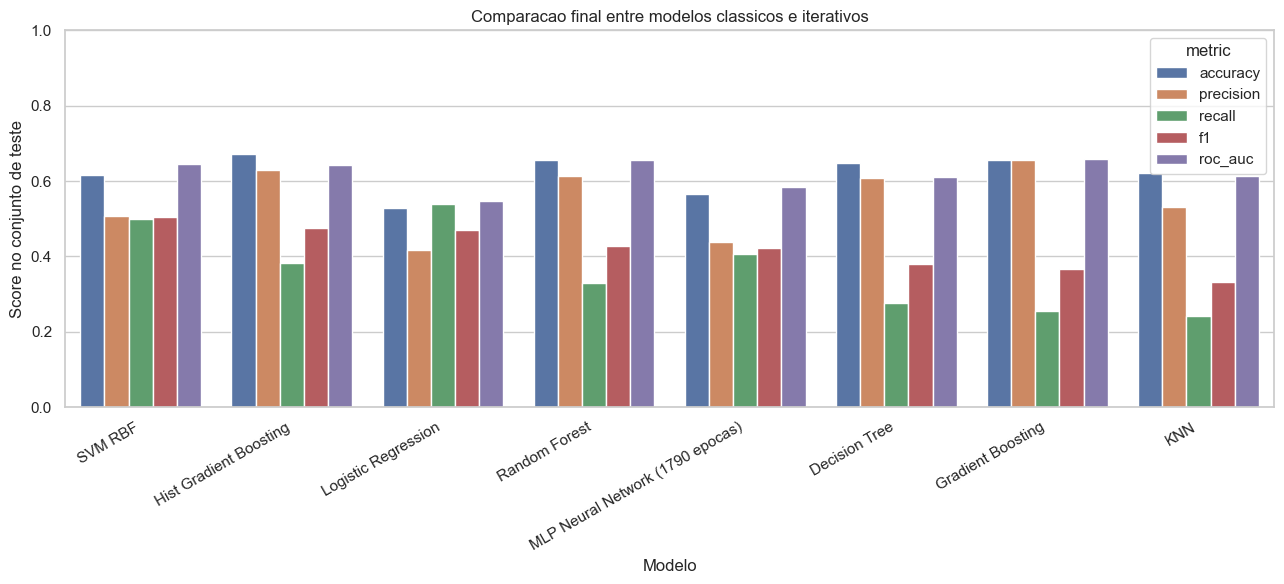

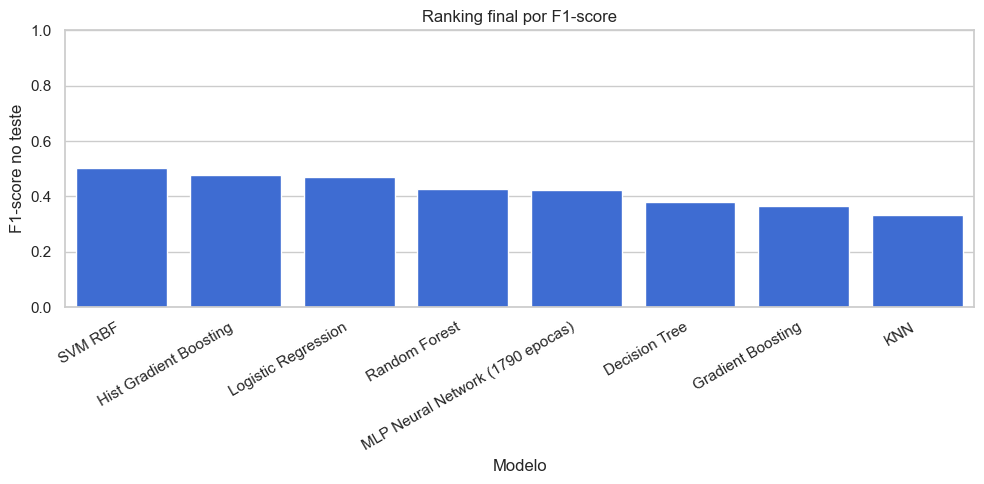

In [83]:
plot_final = final_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_final, x="model", y="score", hue="metric")
plt.title("Comparacao final entre modelos classicos e iterativos")
plt.xlabel("Modelo")
plt.ylabel("Score no conjunto de teste")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "final_model_comparison.png", dpi=160)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=final_comparison, x="model", y="f1", color="#2563eb")
plt.title("Ranking final por F1-score")
plt.xlabel("Modelo")
plt.ylabel("F1-score no teste")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(REPORT_DIR / "final_f1_ranking.png", dpi=160)
plt.show()


### Matrizes de confusao por modelo

As matrizes de confusao mostram onde cada modelo acerta e erra. Para este problema, e especialmente importante observar falsos positivos e falsos negativos, pois classificar agua inadequada como potavel e mais grave do que o erro contrario.


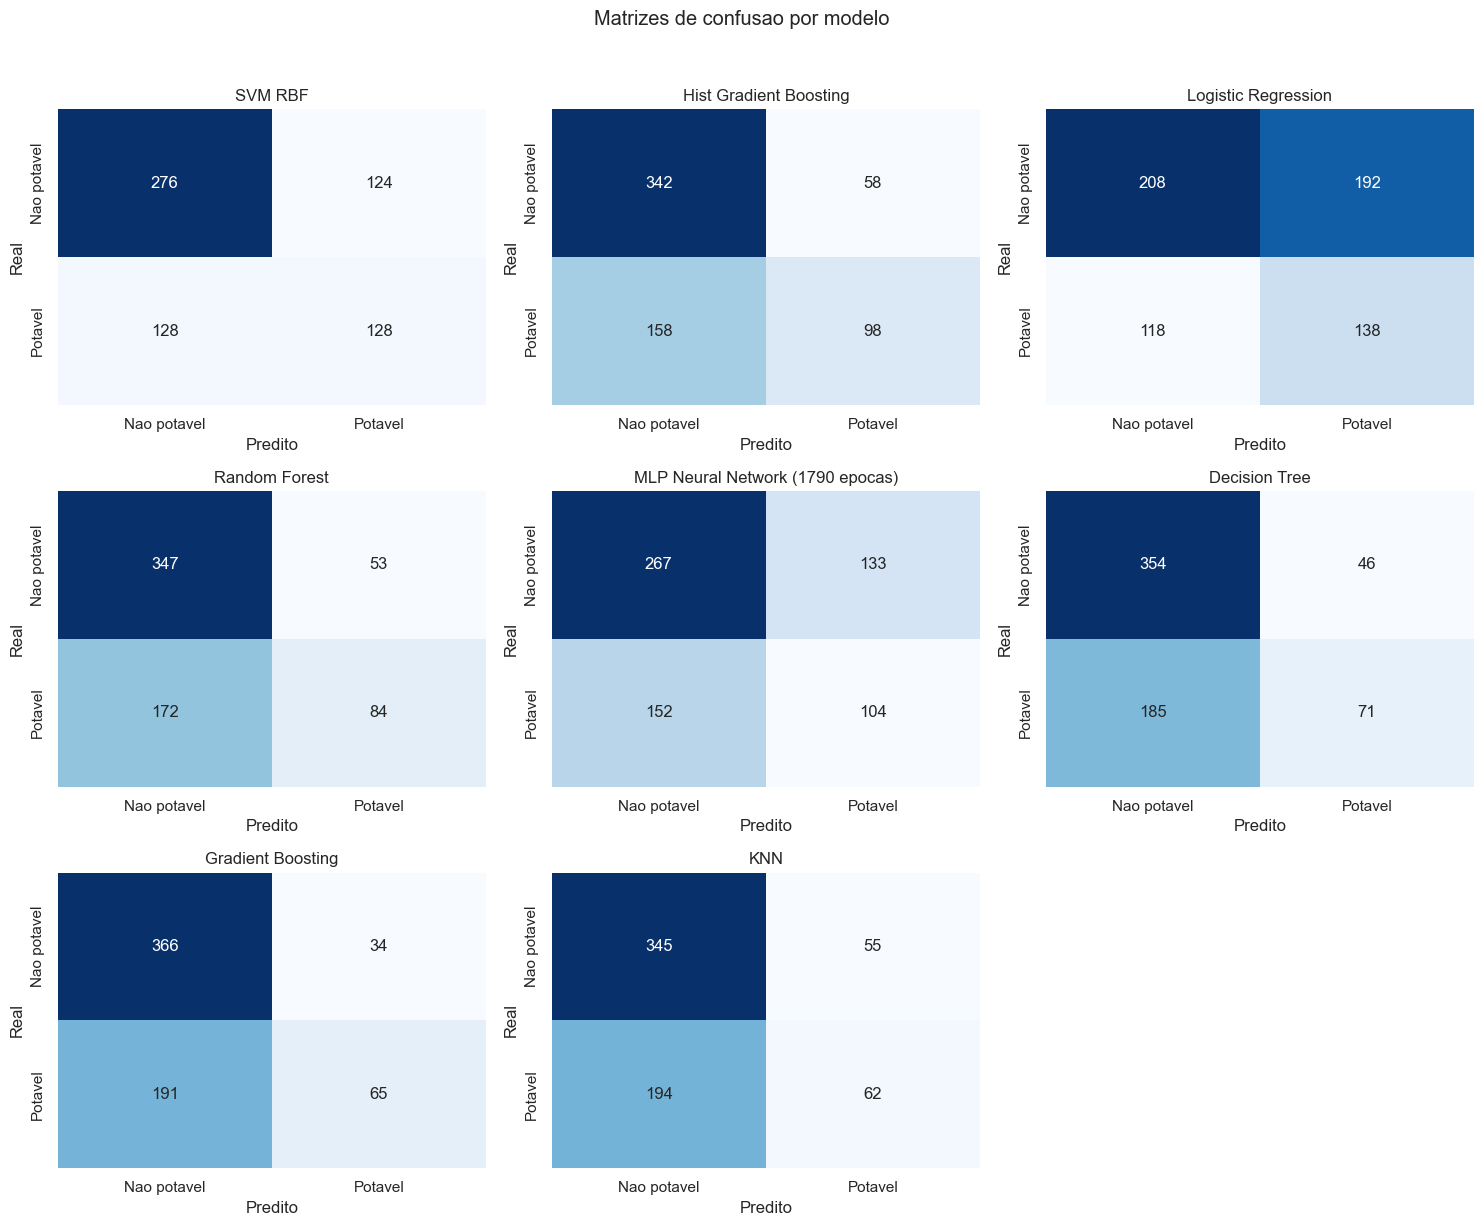

In [84]:
model_names = list(final_comparison["model"])
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for axis, model_name in zip(axes, model_names):
    cm = confusion_matrix(y_test, final_predictions[model_name])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Nao potavel", "Potavel"],
        yticklabels=["Nao potavel", "Potavel"],
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predito")
    axis.set_ylabel("Real")

for axis in axes[n_models:]:
    axis.axis("off")

plt.suptitle("Matrizes de confusao por modelo", y=1.02)
plt.tight_layout()
plt.savefig(REPORT_DIR / "all_confusion_matrices.png", dpi=160)
plt.show()


In [85]:
classification_reports = []
for model_name in model_names:
    report = classification_report(
        y_test,
        final_predictions[model_name],
        target_names=["nao_potavel", "potavel"],
        output_dict=True,
        zero_division=0,
    )
    for label in ["nao_potavel", "potavel"]:
        classification_reports.append({
            "model": model_name,
            "class": label,
            "precision": report[label]["precision"],
            "recall": report[label]["recall"],
            "f1_score": report[label]["f1-score"],
            "support": report[label]["support"],
        })

classification_reports_df = pd.DataFrame(classification_reports)
classification_reports_df.to_csv(REPORT_DIR / "classification_reports_by_model.csv", index=False)
display(classification_reports_df)


,model,class,precision,recall,f1_score,support
0,SVM RBF,nao_potavel,0.683168,0.690000,0.686567,400.0
1,SVM RBF,potavel,0.507937,0.500000,0.503937,256.0
2,Hist Gradient Boosting,nao_potavel,0.684000,0.855000,0.760000,400.0
3,Hist Gradient Boosting,potavel,0.628205,0.382812,0.475728,256.0
4,Logistic Regression,nao_potavel,0.638037,0.520000,0.573003,400.0
5,Logistic Regression,potavel,0.418182,0.539062,0.470990,256.0
6,Random Forest,nao_potavel,0.668593,0.867500,0.755169,400.0
7,Random Forest,potavel,0.613139,0.328125,0.427481,256.0
8,MLP Neural Network (1790 epocas),nao_potavel,0.637232,0.667500,0.652015,400.0
9,MLP Neural Network (1790 epocas),potavel,0.438819,0.406250,0.421907,256.0


## 9. Salvamento do melhor modelo

In [86]:
model_path = MODEL_DIR / 'astrowater_potability_model.joblib'
metadata_path = MODEL_DIR / 'astrowater_potability_model_metadata.json'

joblib.dump(best_pipeline, model_path)

metadata = {
    'project': 'AstroWater AI',
    'dataset': 'adityakadiwal/water-potability',
    'target': target,
    'features': features,
    'best_model': best_model_name,
    'selection_metric': 'f1',
    'test_metrics': test_results.iloc[0].to_dict(),
    'safety_note': 'POC educacional para triagem; nao substitui laudo laboratorial oficial.',
}

metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')

print('Modelo salvo em:', model_path)
print('Metadados salvos em:', metadata_path)

Modelo salvo em: c:\Users\felip\OneDrive\Documentos\FIAP 2 ano\gs1\machine-learning\models\astrowater_potability_model.joblib
Metadados salvos em: c:\Users\felip\OneDrive\Documentos\FIAP 2 ano\gs1\machine-learning\models\astrowater_potability_model_metadata.json


## 10. Exemplo de predicao para integrar com backend

O backend pode carregar o arquivo `.joblib` e chamar `predict_proba` para gerar a probabilidade de potabilidade. Para a demo, este exemplo simula uma leitura parecida com o payload do AstroWater AI.

In [87]:
loaded_model = joblib.load(model_path)

sample = pd.DataFrame([
    {
        'ph': 6.8,
        'Hardness': 190.0,
        'Solids': 18000.0,
        'Chloramines': 7.2,
        'Sulfate': 330.0,
        'Conductivity': 420.0,
        'Organic_carbon': 12.0,
        'Trihalomethanes': 65.0,
        'Turbidity': 3.5,
    }
])

prediction = int(loaded_model.predict(sample)[0])
probability = float(loaded_model.predict_proba(sample)[0][1])

result = {
    'prediction': prediction,
    'label': 'potavel' if prediction == 1 else 'nao potavel',
    'potabilityProbability': round(probability, 4),
}

result

{'prediction': 0, 'label': 'nao potavel', 'potabilityProbability': 0.2315}

## Como explicar no PDF/video

Frase sugerida:

> O AstroWater AI utiliza um classificador supervisionado treinado com um dataset publico de potabilidade da agua. O modelo tabular complementa o motor de regras, a telemetria simulada no ESP32 e a visao computacional do Raspberry Pi, gerando uma segunda opiniao probabilistica para apoiar a triagem de risco.

Limite etico:

> A previsao do modelo nao substitui testes laboratoriais oficiais e deve ser interpretada como apoio inicial a decisao.